In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
# Load test data - X_test is scaled (for LR/LSTM), X_test_unscaled for DT/RF
X_test = np.load("../dataset/X_test_scaled.npy")
X_test_unscaled = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

target_encoder = joblib.load("../models/target_encoder.pkl")

In [3]:
# Load models
lr = joblib.load("../models/logistic_regression.pkl")
dt = joblib.load("../models/decision_tree.pkl")
rf = joblib.load("../models/random_forest.pkl")
lstm_model = load_model("../models/lstm_model.keras")

In [4]:
# Get predictions - use correct data for each model
lr_pred = lr.predict(X_test)  # Scaled data for Logistic Regression
dt_pred = dt.predict(X_test_unscaled)  # Unscaled data for Decision Tree
rf_pred = rf.predict(X_test_unscaled)  # Unscaled data for Random Forest

# LSTM uses scaled data reshaped
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
lstm_pred_prob = lstm_model.predict(X_test_lstm)
lstm_pred = np.argmax(lstm_pred_prob, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [5]:
def evaluate(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [6]:
results = []

results.append(evaluate("Logistic Regression", y_test, lr_pred))
results.append(evaluate("Decision Tree", y_test, dt_pred))
results.append(evaluate("Random Forest", y_test, rf_pred))
results.append(evaluate("LSTM", y_test, lstm_pred))

results = pd.DataFrame(results)
results = results.sort_values(by="Accuracy", ascending=False)

results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1 Score": "{:.2%}"
})

results

,Model,Accuracy,Precision,Recall,F1 Score
3,LSTM,0.888000,0.887762,0.888000,0.887560
0,Logistic Regression,0.882667,0.882453,0.882667,0.882395
2,Random Forest,0.865333,0.866232,0.865333,0.864363
1,Decision Tree,0.853000,0.852345,0.853000,0.852410


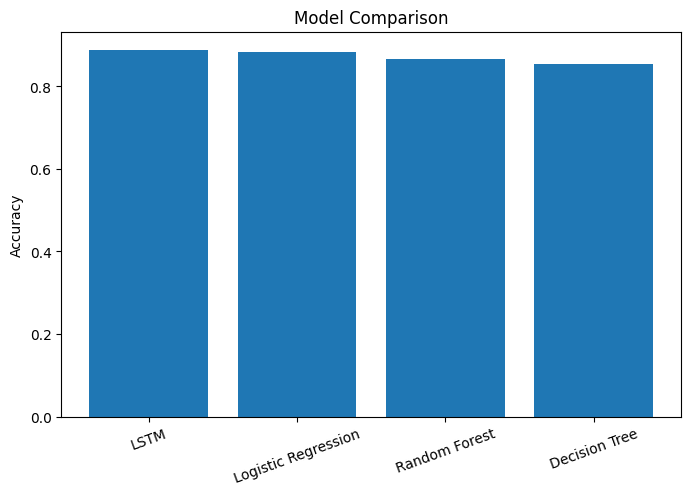

In [7]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()